# Banco de Dados de Análise de Crédito

## Objetivo
 
Construir um modelo de classificação binária para prever o **risco de crédito** de clientes,
com base em variáveis financeiras, pessoais e comportamentais.
 
| | |
|---|---|
| **Variável Alvo** | `risco_credito` |
| **Tipo** | Binária: `0` = bom pagador, `1` = mau pagador |
| **Tarefa** | Classificação supervisionada |
 
---
 
## Fonte dos Dados
 
- Dataset: German Credit Data
- Arquivo: `german_credit_data.csv`
- Armazenamento: banco SQLite (`analise_credito_alemao.db`), tabela `credito_clientes`
---
 
## Variáveis do Dataset
 
### Numéricas
| Coluna | Descrição |
|---|---|
| `duracao_meses` | Duração do crédito em meses |
| `valor_credito` | Valor do crédito solicitado |
| `idade` | Idade do cliente |
 
### Categóricas Ordinais
| Coluna | Descrição |
|---|---|
| `status_conta_corrente` | Situação da conta corrente |
| `poupanca_investimento` | Nível de poupança/investimento |
| `tempo_emprego_atual` | Tempo no emprego atual |
| `taxa_parcelamento_renda` | Taxa de parcelamento em relação à renda |
| `residencia_atual_desde` | Tempo na residência atual |
| `numero_creditos_existentes` | Quantidade de créditos ativos |
| `dependentes` | Número de pessoas dependentes |
 
### Categóricas Nominais
| Coluna | Descrição |
|---|---|
| `historico_credito` | Histórico de pagamentos |
| `proposito` | Finalidade do crédito |
| `status_pessoal_sexo` | Estado civil e sexo |
| `outros_fiadores` | Existência de fiadores |
| `propriedade` | Tipo de propriedade |
| `outros_planos_parcelamento` | Outros planos de parcelamento |
| `habitacao` | Tipo de habitação |
| `trabalho` | Cargo/ocupação |
| `telefone` | Possui telefone |
| `trabalhador_estrangeiro` | É trabalhador estrangeiro |
 
---

In [77]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from importlib import reload
import sqlite3 # Usar SQLite para facilitar o upload de um arquivo único ao GitHub
import seaborn as sns


pd.set_option('display.max_columns', None)

In [78]:
# Carregar dados
df = pd.read_csv('data/german_credit_data.csv')

# Dicionário de tradução (ajuste conforme sua interpretação das variáveis)
colunas_pt = {
    'laufkont': 'status_conta_corrente',
    'laufzeit': 'duracao_meses',
    'moral': 'historico_credito',
    'verw': 'proposito',
    'hoehe': 'valor_credito',
    'sparkont': 'poupanca_investimento',
    'beszeit': 'tempo_emprego_atual',
    'rate': 'taxa_parcelamento_renda',
    'famges': 'status_pessoal_sexo',
    'buerge': 'outros_fiadores',
    'wohnzeit': 'residencia_atual_desde',
    'verm': 'propriedade',
    'alter': 'idade',
    'weitkred': 'outros_planos_parcelamento',
    'wohn': 'habitacao',
    'bishkred': 'numero_creditos_existentes',
    'beruf': 'trabalho',
    'pers': 'dependentes',
    'telef': 'telefone',
    'gastarb': 'trabalhador_estrangeiro',
    'kredit': 'risco_credito'
}

df.rename(columns=colunas_pt, inplace=True)

# Criando o banco de dados local (gerando um arquivo .db)
conn = sqlite3.connect('analise_credito_alemao.db')
df.to_sql('credito_cliente', conn, if_exists='replace', index=False)

1000

In [79]:
def run_query(query):
    return pd.read_sql_query(query, conn)

# Limpeza de Dados

In [96]:
query = """
SELECT
    -- ========================
    -- VARIÁVEIS NUMÉRICAS
    -- ========================

    CASE 
        WHEN duracao_meses <= 0 THEN NULL
        ELSE duracao_meses 
    END AS duracao_meses,

    CASE 
        WHEN valor_credito <= 0 THEN NULL
        ELSE valor_credito 
    END AS valor_credito,

    CASE 
        WHEN idade < 18 OR idade > 100 THEN NULL
        ELSE idade 
    END AS idade,

    -- ========================
    -- VARIÁVEL ALVO
    -- ========================

    CASE 
        WHEN risco_credito NOT IN (0,1) THEN NULL
        ELSE risco_credito 
    END AS risco_credito,

    
    -- ========================
    -- VARIÁVEL CATEGÓRICAS (com cast para INTEGER)
    -- ========================

     CASE
        WHEN CAST(status_conta_corrente AS INTEGER) BETWEEN 0 AND 4
        THEN CAST(status_conta_corrente AS INTEGER)
        ELSE NULL
    END AS status_conta_corrente,

    CASE
        WHEN CAST(historico_credito AS INTEGER) BETWEEN 0 AND 4
        THEN CAST(historico_credito AS INTEGER)
        ELSE NULL
    END AS historico_credito,

    CASE
        WHEN CAST(proposito AS INTEGER) BETWEEN 0 AND 10
        THEN CAST(proposito AS INTEGER)
        ELSE NULL
    END AS proposito,

    CASE
        WHEN CAST(poupanca_investimento AS INTEGER) BETWEEN 0 AND 6
        THEN CAST(poupanca_investimento AS INTEGER)
        ELSE NULL
    END AS poupanca_investimento,

    CASE
        WHEN CAST(tempo_emprego_atual AS INTEGER) BETWEEN 0 AND 5
        THEN CAST(tempo_emprego_atual AS INTEGER)
        ELSE NULL
    END AS tempo_emprego_atual,

    CASE
        WHEN CAST(taxa_parcelamento_renda AS INTEGER) BETWEEN 0 AND 4
        THEN CAST(taxa_parcelamento_renda AS INTEGER)
        ELSE NULL
    END AS taxa_parcelamento_renda,

    CASE
        WHEN CAST(status_pessoal_sexo AS INTEGER) BETWEEN 0 AND 4
        THEN CAST(status_pessoal_sexo AS INTEGER)
        ELSE NULL
    END AS status_pessoal_sexo,

    CASE
        WHEN CAST(outros_fiadores AS INTEGER) BETWEEN 0 AND 3
        THEN CAST(outros_fiadores AS INTEGER)
        ELSE NULL
    END AS outros_fiadores,

    CASE
        WHEN CAST(residencia_atual_desde AS INTEGER) BETWEEN 0 AND 4
        THEN CAST(residencia_atual_desde AS INTEGER)
        ELSE NULL
    END AS residencia_atual_desde,

    CASE
        WHEN CAST(propriedade AS INTEGER) BETWEEN 0 AND 4
        THEN CAST(propriedade AS INTEGER)
        ELSE NULL
    END AS propriedade,

    CASE
        WHEN CAST(outros_planos_parcelamento AS INTEGER) BETWEEN 0 AND 3
        THEN CAST(outros_planos_parcelamento AS INTEGER)
        ELSE NULL
    END AS outros_planos_parcelamento,

    CASE
        WHEN CAST(habitacao AS INTEGER) BETWEEN 0 AND 3
        THEN CAST(habitacao AS INTEGER)
        ELSE NULL
    END AS habitacao,

    CASE
        WHEN CAST(numero_creditos_existentes AS INTEGER) BETWEEN 0 AND 4
        THEN CAST(numero_creditos_existentes AS INTEGER)
        ELSE NULL
    END AS numero_creditos_existentes,

    CASE
        WHEN CAST(trabalho AS INTEGER) BETWEEN 0 AND 4
        THEN CAST(trabalho AS INTEGER)
        ELSE NULL
    END AS trabalho,

    CASE
        WHEN CAST(dependentes AS INTEGER) BETWEEN 0 AND 2
        THEN CAST(dependentes AS INTEGER)
        ELSE NULL
    END AS dependentes,

    CASE
        WHEN CAST(telefone AS INTEGER) BETWEEN 0 AND 2
        THEN CAST(telefone AS INTEGER)
        ELSE NULL
    END AS telefone,

    CASE
        WHEN CAST(trabalhador_estrangeiro AS INTEGER) BETWEEN 0 AND 2
        THEN CAST(trabalhador_estrangeiro AS INTEGER)
        ELSE NULL
    END AS trabalhador_estrangeiro
    

FROM credito_cliente

-- Foco apenas no target
WHERE risco_credito IN (0,1)
"""

df_limpo = run_query(query)

print(f"\nNulos por coluna:\n{df_limpo.isnull().sum()}")
print(f"\nValores Duplicados:\n{df_limpo.duplicated().sum()}")

# Substitui valores nulos pela mediana da coluna
df_limpo.fillna(df_limpo.median(), inplace=True)
df_limpo = df_limpo.drop_duplicates()

print(f"Linhas originais  : {len(run_query('SELECT * FROM credito_cliente'))}")
print(f"Linhas após limpeza: {len(df_limpo)}")



Nulos por coluna:
duracao_meses                 0
valor_credito                 0
idade                         0
risco_credito                 0
status_conta_corrente         0
historico_credito             0
proposito                     0
poupanca_investimento         0
tempo_emprego_atual           0
taxa_parcelamento_renda       0
status_pessoal_sexo           0
outros_fiadores               0
residencia_atual_desde        0
propriedade                   0
outros_planos_parcelamento    0
habitacao                     0
numero_creditos_existentes    0
trabalho                      0
dependentes                   0
telefone                      0
trabalhador_estrangeiro       0
dtype: int64

Valores Duplicados:
0
Linhas originais  : 1000
Linhas após limpeza: 1000


In [97]:
# Verificar se o dataset está balanceado
df_limpo["risco_credito"].value_counts()

risco_credito
1    700
0    300
Name: count, dtype: int64

In [98]:
# ==========================================
# MAPEAMENTO DAS CATEGORIAS PARA PORTUGUÊS
# ==========================================

status_conta_corrente = {
    1: 'sem conta corrente',
    2: 'saldo menor que 0 DM',
    3: 'saldo entre 0 e 200 DM',
    4: 'saldo maior ou igual a 200 DM'
}

historico_credito = {
    0: 'atrasos anteriores no pagamento',
    1: 'conta crítica/outros créditos em outros bancos',
    2: 'nenhum crédito tomado/todos pagos corretamente',
    3: 'créditos existentes pagos corretamente até agora',
    4: 'todos os créditos neste banco pagos corretamente'
}

proposito = {
    0: 'outros',
    1: 'carro novo',
    2: 'carro usado',
    3: 'móveis/equipamentos',
    4: 'rádio/televisão',
    5: 'eletrodomésticos',
    6: 'reparos',
    7: 'educação',
    8: 'férias',
    9: 'recapacitação profissional',
    10: 'negócios'
}

poupanca_investimento = {
    1: 'desconhecido/sem poupança',
    2: 'menos de 100 DM',
    3: 'entre 100 e 500 DM',
    4: 'entre 500 e 1000 DM',
    5: '1000 DM ou mais'
}

tempo_emprego_atual = {
    1: 'desempregado',
    2: 'menos de 1 ano',
    3: 'entre 1 e 4 anos',
    4: 'entre 4 e 7 anos',
    5: '7 anos ou mais'
}

taxa_parcelamento_renda = {
    1: '35% ou mais',
    2: 'entre 25% e 35%',
    3: 'entre 20% e 25%',
    4: 'menos de 20%'
}

status_pessoal_sexo = {
    1: 'homem divorciado/separado',
    2: 'mulher não solteira ou homem solteiro',
    3: 'homem casado/viúvo',
    4: 'mulher solteira'
}

outros_fiadores = {
    1: 'nenhum',
    2: 'co-aplicante',
    3: 'fiador'
}

residencia_atual_desde = {
    1: 'menos de 1 ano',
    2: 'entre 1 e 4 anos',
    3: 'entre 4 e 7 anos',
    4: '7 anos ou mais'
}

propriedade = {
    1: 'desconhecido/sem propriedade',
    2: 'carro ou outro bem',
    3: 'consórcio/poupança seguro de vida',
    4: 'imóvel'
}

outros_planos_parcelamento = {
    1: 'banco',
    2: 'lojas',
    3: 'nenhum'
}

habitacao = {
    1: 'gratuita',
    2: 'alugada',
    3: 'própria'
}

trabalho = {
    1: 'desempregado/não qualificado não residente',
    2: 'não qualificado residente',
    3: 'funcionário qualificado/oficial',
    4: 'gerente/autônomo/altamente qualificado'
}

numero_creditos_existentes = {
    1: '1',
    2: '2 a 3',
    3: '4 a 5',
    4: '6 ou mais'
}

dependentes = {
    1: '3 ou mais',
    2: '0 a 2'
}

telefone = {
    1: 'não',
    2: 'sim (no nome do cliente)'
}

trabalhador_estrangeiro = {
    1: 'sim',
    2: 'não'
}

# risco_credito = {
#     0: 'baixo risco',
#     1: 'alto risco'
# }


# ==========================================
# APLICANDO O MAPEAMENTO
# ==========================================

df_limpo['status_conta_corrente'] = df_limpo['status_conta_corrente'].map(status_conta_corrente)

df_limpo['historico_credito'] = df_limpo['historico_credito'].map(historico_credito)

df_limpo['proposito'] = df_limpo['proposito'].map(proposito)

df_limpo['poupanca_investimento'] = df_limpo['poupanca_investimento'].map(poupanca_investimento)

df_limpo['tempo_emprego_atual'] = df_limpo['tempo_emprego_atual'].map(tempo_emprego_atual)

df_limpo['taxa_parcelamento_renda'] = df_limpo['taxa_parcelamento_renda'].map(taxa_parcelamento_renda)

df_limpo['status_pessoal_sexo'] = df_limpo['status_pessoal_sexo'].map(status_pessoal_sexo)

df_limpo['outros_fiadores'] = df_limpo['outros_fiadores'].map(outros_fiadores)

df_limpo['residencia_atual_desde'] = df_limpo['residencia_atual_desde'].map(residencia_atual_desde)

df_limpo['propriedade'] = df_limpo['propriedade'].map(propriedade)

df_limpo['outros_planos_parcelamento'] = df_limpo['outros_planos_parcelamento'].map(outros_planos_parcelamento)

df_limpo['habitacao'] = df_limpo['habitacao'].map(habitacao)

df_limpo['trabalho'] = df_limpo['trabalho'].map(trabalho)

df_limpo['numero_creditos_existentes'] = df_limpo['numero_creditos_existentes'].map(numero_creditos_existentes)

df_limpo['dependentes'] = df_limpo['dependentes'].map(dependentes)

df_limpo['telefone'] = df_limpo['telefone'].map(telefone)

df_limpo['trabalhador_estrangeiro'] = df_limpo['trabalhador_estrangeiro'].map(trabalhador_estrangeiro)

# df_limpo['risco_credito'] = df_limpo['risco_credito'].map(risco_credito)

In [99]:
df_limpo.head()

,duracao_meses,valor_credito,idade,risco_credito,status_conta_corrente,historico_credito,proposito,poupanca_investimento,tempo_emprego_atual,taxa_parcelamento_renda,status_pessoal_sexo,outros_fiadores,residencia_atual_desde,propriedade,outros_planos_parcelamento,habitacao,numero_creditos_existentes,trabalho,dependentes,telefone,trabalhador_estrangeiro
0,18,1049,21,1,sem conta corrente,todos os créditos neste banco pagos corretamente,carro usado,desconhecido/sem poupança,menos de 1 ano,menos de 20%,mulher não solteira ou homem solteiro,nenhum,7 anos ou mais,carro ou outro bem,nenhum,gratuita,1,funcionário qualificado/oficial,0 a 2,não,não
1,9,2799,36,1,sem conta corrente,todos os créditos neste banco pagos corretamente,outros,desconhecido/sem poupança,entre 1 e 4 anos,entre 25% e 35%,homem casado/viúvo,nenhum,entre 1 e 4 anos,desconhecido/sem propriedade,nenhum,gratuita,2 a 3,funcionário qualificado/oficial,3 ou mais,não,não
2,12,841,23,1,saldo menor que 0 DM,nenhum crédito tomado/todos pagos corretamente,recapacitação profissional,menos de 100 DM,entre 4 e 7 anos,entre 25% e 35%,mulher não solteira ou homem solteiro,nenhum,7 anos ou mais,desconhecido/sem propriedade,nenhum,gratuita,1,não qualificado residente,0 a 2,não,não
3,12,2122,39,1,sem conta corrente,todos os créditos neste banco pagos corretamente,outros,desconhecido/sem poupança,entre 1 e 4 anos,entre 20% e 25%,homem casado/viúvo,nenhum,entre 1 e 4 anos,desconhecido/sem propriedade,nenhum,gratuita,2 a 3,não qualificado residente,3 ou mais,não,sim
4,12,2171,38,1,sem conta corrente,todos os créditos neste banco pagos corretamente,outros,desconhecido/sem poupança,entre 1 e 4 anos,menos de 20%,homem casado/viúvo,nenhum,7 anos ou mais,carro ou outro bem,banco,alugada,2 a 3,não qualificado residente,0 a 2,não,sim


In [100]:
df_limpo.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   duracao_meses               1000 non-null   int64
 1   valor_credito               1000 non-null   int64
 2   idade                       1000 non-null   int64
 3   risco_credito               1000 non-null   int64
 4   status_conta_corrente       1000 non-null   str  
 5   historico_credito           1000 non-null   str  
 6   proposito                   1000 non-null   str  
 7   poupanca_investimento       1000 non-null   str  
 8   tempo_emprego_atual         1000 non-null   str  
 9   taxa_parcelamento_renda     1000 non-null   str  
 10  status_pessoal_sexo         1000 non-null   str  
 11  outros_fiadores             1000 non-null   str  
 12  residencia_atual_desde      1000 non-null   str  
 13  propriedade                 1000 non-null   str  
 14  outros_planos_parcel

# EDA

## Análise Univariada

### Estatísticas

In [85]:
numerical_cols = df_limpo.select_dtypes(include=[np.number]).columns
colunas = df_limpo.select_dtypes(include=[np.number]).columns
resultados = []

for coluna in colunas:
    serie = df_limpo[coluna]

    estatisticas = {
        "coluna": coluna,
        
        # Tendência central
        "media": serie.mean(),
        "mediana": serie.median(),
        "moda": serie.mode().iloc[0] if not serie.mode().empty else np.nan,

        # Dispersão
        "variancia": serie.var(),
        "desvio_padrao": serie.std(),
        "coeficiente_variacao": (
            serie.std() / serie.mean()
            if serie.mean() != 0 else np.nan
        ),

        # Extremos
        "minimo": serie.min(),
        "maximo": serie.max(),
        "amplitude": serie.max() - serie.min(),

        # Quartis
        "q1": serie.quantile(0.25),
        "q2_mediana": serie.quantile(0.50),
        "q3": serie.quantile(0.75),
        "iqr": serie.quantile(0.75) - serie.quantile(0.25),

        # Distribuição
        "assimetria": serie.skew(),
        "curtose": serie.kurt(),

        # Percentis adicionais
        "p5": serie.quantile(0.05),
        "p95": serie.quantile(0.95),

        # Outliers pelo método IQR
        "outliers_iqr": (
            ((serie < (serie.quantile(0.25) - 1.5 * (
                serie.quantile(0.75) - serie.quantile(0.25)))) |
                (serie > (serie.quantile(0.75) + 1.5 * (
                serie.quantile(0.75) - serie.quantile(0.25))))).sum()
        )
    }

    resultados.append(estatisticas)

# Cria dataframe estatisticas
df_estatisticas = pd.DataFrame(resultados)
df_estatisticas


,coluna,media,mediana,moda,variancia,desvio_padrao,coeficiente_variacao,minimo,maximo,amplitude,q1,q2_mediana,q3,iqr,assimetria,curtose,p5,p95,outliers_iqr
0,duracao_meses,20.903,18.0,24,1.454150e+02,12.058814,0.576894,4,72,68,12.0,18.0,24.00,12.00,1.094184,0.919781,6.00,48.0,70
1,valor_credito,3271.248,2319.5,1258,7.967927e+06,2822.751760,0.862898,250,18424,18174,1365.5,2319.5,3972.25,2606.75,1.949594,4.292481,708.95,9162.7,72
2,idade,35.542,33.0,27,1.288831e+02,11.352670,0.319416,19,75,56,27.0,33.0,42.00,15.00,1.024712,0.620529,22.00,60.0,23


## Gráficos

### Análise da Distribuição das Variáveis Numéricas

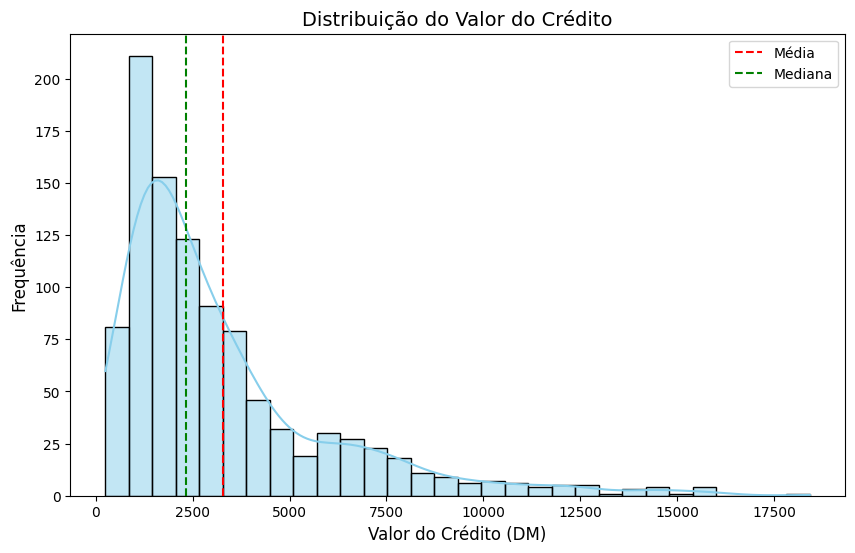

In [101]:
plt.figure(figsize=(10, 6))
sns.histplot(df_limpo['valor_credito'], bins=30, kde=True, color='skyblue')
plt.title('Distribuição do Valor do Crédito', fontsize=14)
plt.xlabel('Valor do Crédito (DM)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.axvline(df_limpo['valor_credito'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df_limpo['valor_credito'].median(), color='green', linestyle='--', label='Mediana')
plt.legend()
plt.show()

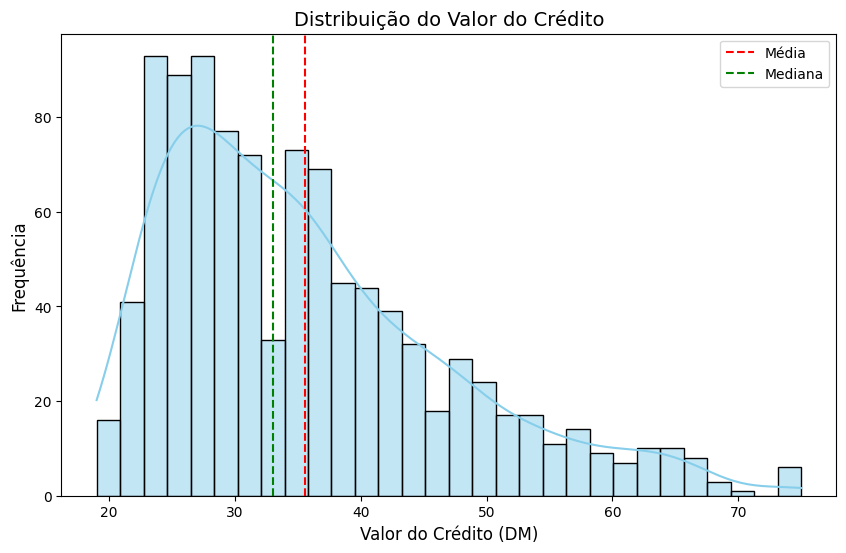

In [102]:
plt.figure(figsize=(10, 6))
sns.histplot(df_limpo['idade'], bins=30, kde=True, color='skyblue')
plt.title('Distribuição do Valor do Crédito', fontsize=14)
plt.xlabel('Valor do Crédito (DM)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.axvline(df_limpo['idade'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df_limpo['idade'].median(), color='green', linestyle='--', label='Mediana')
plt.legend()
plt.show()

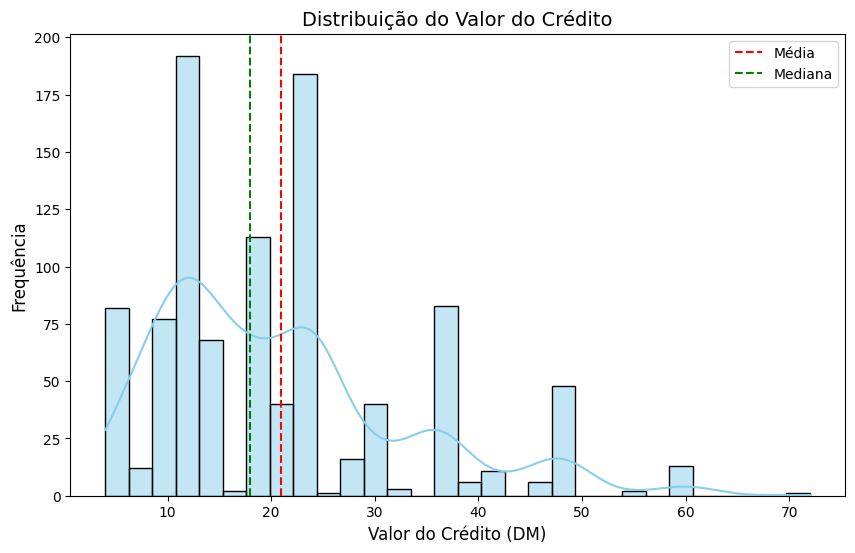

In [103]:

plt.figure(figsize=(10, 6))
sns.histplot(df_limpo['duracao_meses'], bins=30, kde=True, color='skyblue')
plt.title('Distribuição do Valor do Crédito', fontsize=14)
plt.xlabel('Valor do Crédito (DM)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.axvline(df_limpo['duracao_meses'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df_limpo['duracao_meses'].median(), color='green', linestyle='--', label='Mediana')
plt.legend()
plt.show()

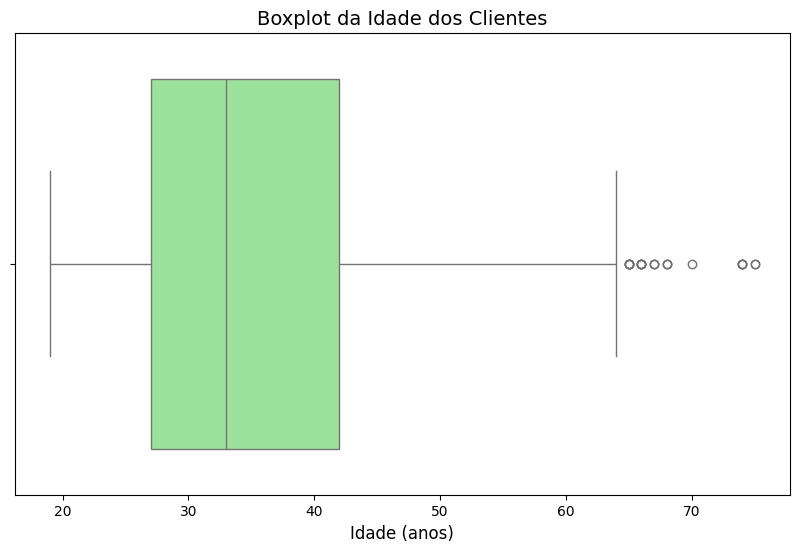

In [104]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_limpo['idade'], color='lightgreen')
plt.title('Boxplot da Idade dos Clientes', fontsize=14)
plt.xlabel('Idade (anos)', fontsize=12)
plt.show()


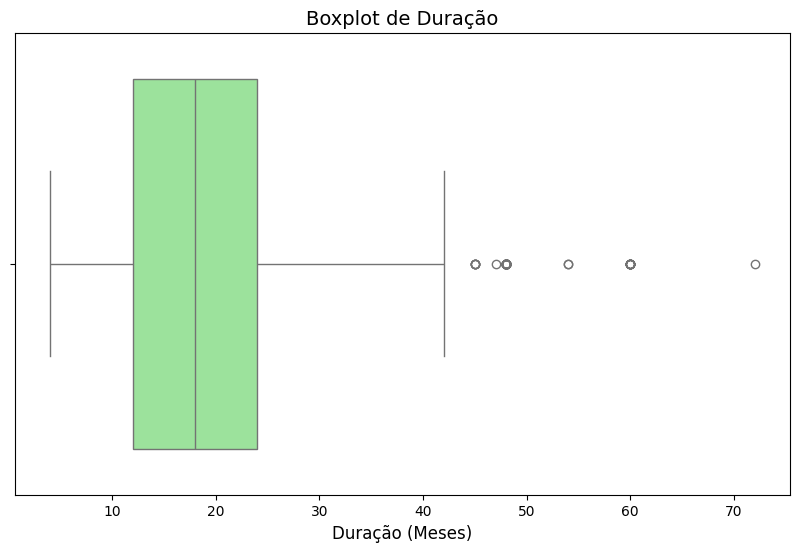

In [105]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_limpo['duracao_meses'], color='lightgreen')
plt.title('Boxplot de Duração', fontsize=14)
plt.xlabel('Duração (Meses)', fontsize=12)
plt.show()

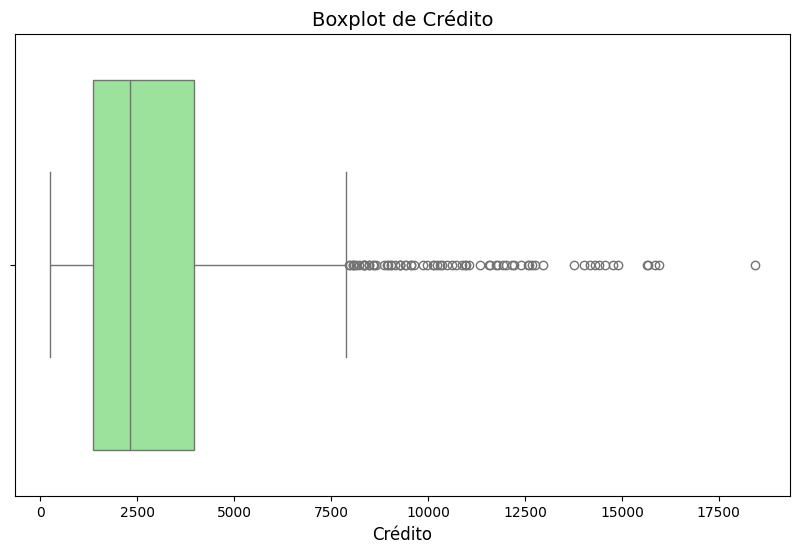

In [106]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_limpo['valor_credito'], color='lightgreen')
plt.title('Boxplot de Crédito', fontsize=14)
plt.xlabel('Crédito', fontsize=12)
plt.show()

### Análise da Distribuição das Variáveis Categóricas

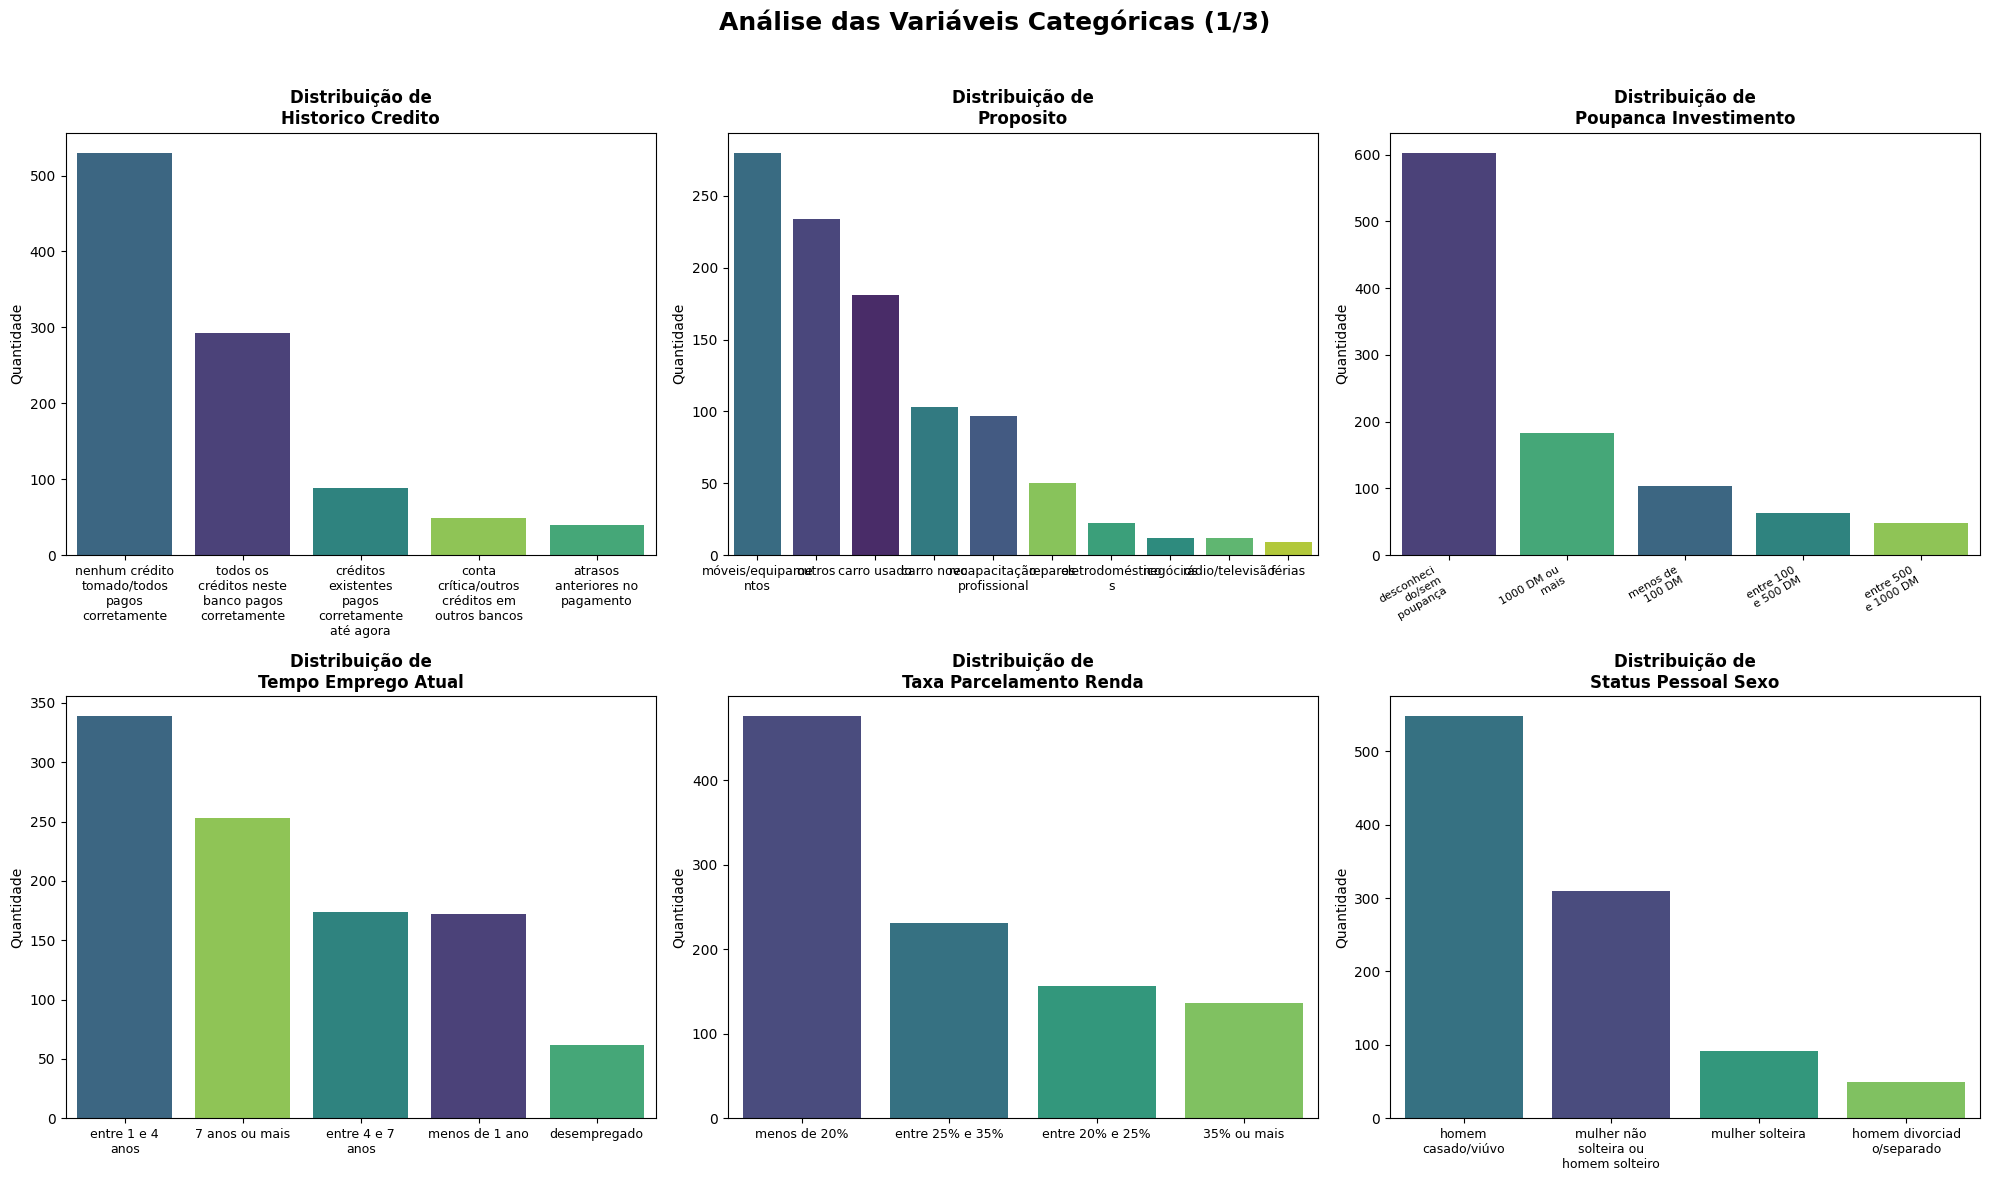

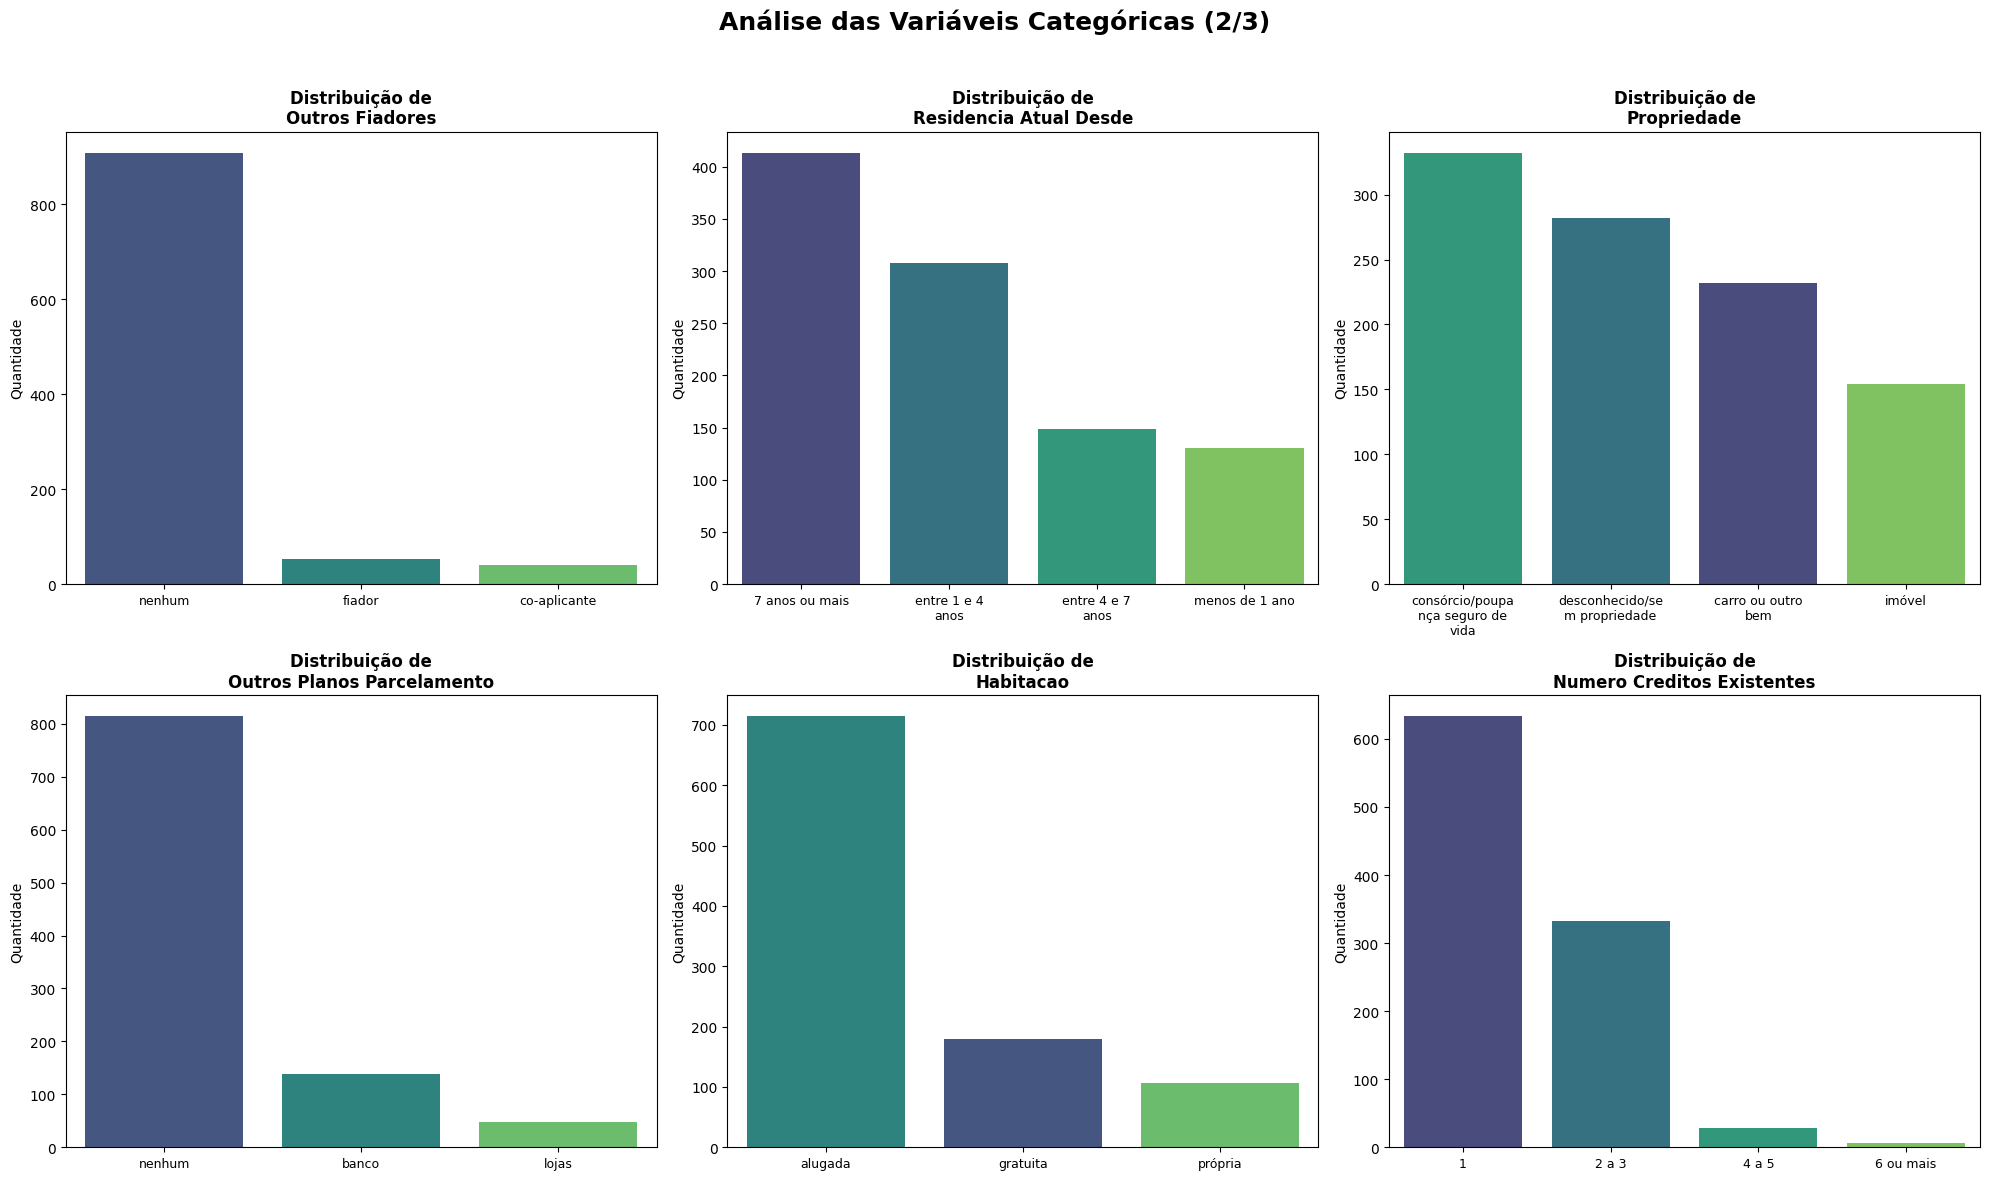

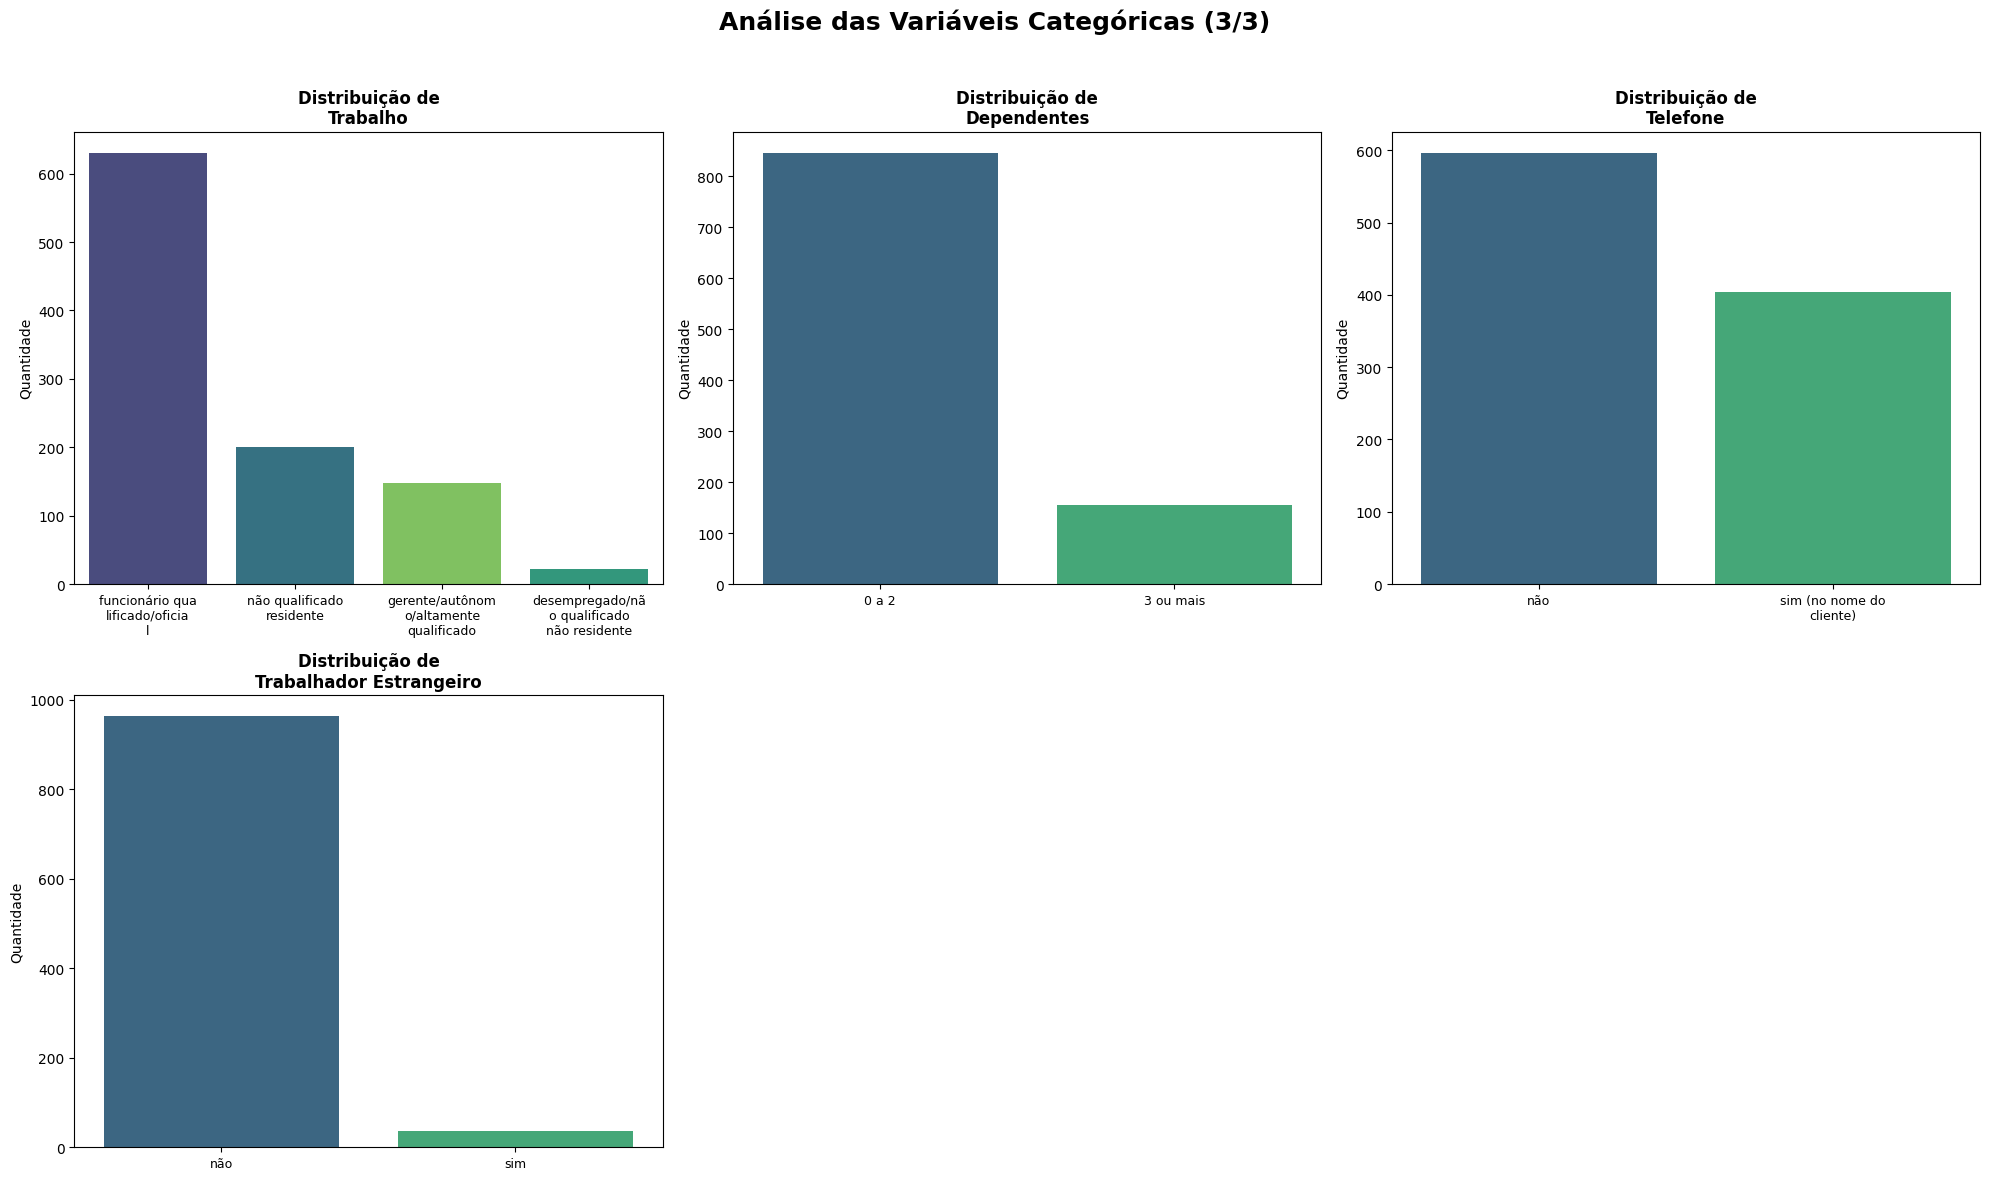

In [107]:
import textwrap

# ==========================================
# COLUNAS CATEGÓRICAS
# ==========================================

categorical_cols = df_limpo.select_dtypes(exclude=[np.number]).columns

# Remove a primeira coluna categórica
categorical_cols = categorical_cols[1:]

# ==========================================
# CONFIGURAÇÕES
# ==========================================

graficos_por_figura = 6

num_figuras = int(np.ceil(len(categorical_cols) / graficos_por_figura))

# ==========================================
# GERAÇÃO DOS GRÁFICOS
# ==========================================

for fig_num in range(num_figuras):

    inicio = fig_num * graficos_por_figura
    fim = inicio + graficos_por_figura

    cols_bloco = categorical_cols[inicio:fim]

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    axes = axes.flatten()

    # ==========================================
    # LOOP DOS GRÁFICOS
    # ==========================================

    for i, col in enumerate(cols_bloco):

        ax = axes[i]

        ordem = df_limpo[col].value_counts().index

        sns.countplot(
            data=df_limpo,
            x=col,
            order=ordem,
            ax=ax,
            hue=col,
            palette='viridis',
            legend=False
        )

        # ==========================================
        # FORMATAÇÃO DAS LABELS
        # ==========================================

        
        if fig_num == 0 and i == 2:
            labels_formatadas = [
                "\n".join(textwrap.wrap(str(label), width=10))
                for label in ordem
            ]

            ax.set_xticks(range(len(ordem)))

            ax.set_xticklabels(
                labels_formatadas,
                rotation=30,
                ha='right',
                fontsize=8
            )

        else:    
            labels_formatadas = [
                "\n".join(textwrap.wrap(str(label), width=15))
                for label in ordem
            ]

            # Corrige warning do set_ticklabels
            ax.set_xticks(range(len(ordem)))
            ax.set_xticklabels(
                labels_formatadas,
                rotation=0,
                fontsize=9
            )

        # ==========================================
        # TÍTULO
        # ==========================================

        titulo = col.replace("_", " ").title()

        ax.set_title(
            f'Distribuição de\n{titulo}',
            fontsize=12,
            fontweight='bold'
        )

        ax.set_xlabel("")
        ax.set_ylabel("Quantidade")

    # ==========================================
    # REMOVE SUBPLOTS VAZIOS
    # ==========================================

    for j in range(len(cols_bloco), len(axes)):
        fig.delaxes(axes[j])

    # ==========================================
    # AJUSTES FINAIS
    # ==========================================

    plt.suptitle(
        f'Análise das Variáveis Categóricas ({fig_num + 1}/{num_figuras})',
        fontsize=18,
        fontweight='bold'
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    plt.show()

### Relação entre Variáveis Numéricas e `risco_credito`


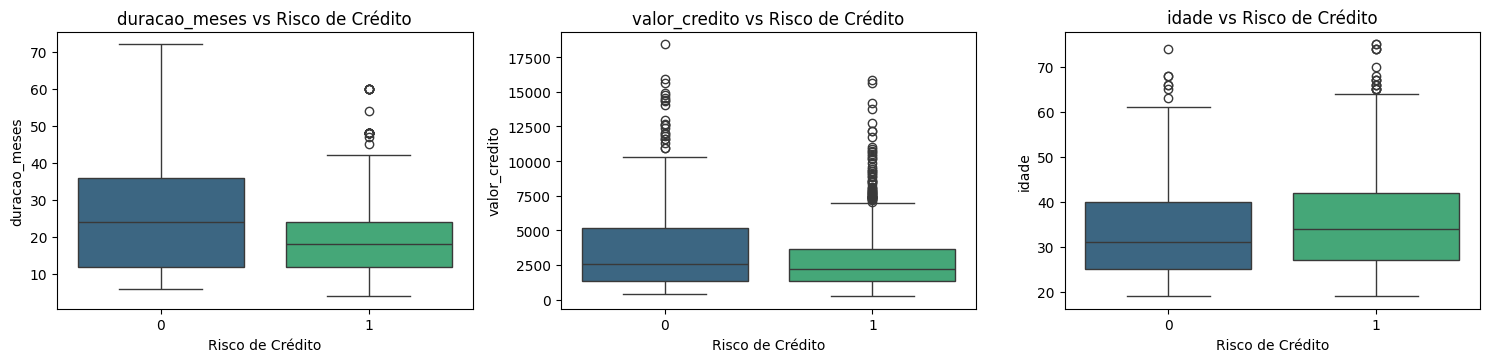

In [112]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)

    sns.boxplot(
        data=df_limpo,
        x='risco_credito',
        y=col,
        hue='risco_credito',   # evita o warning
        palette='viridis',
        legend=False
    )

    plt.title(f'{col} vs Risco de Crédito')
    plt.xlabel('Risco de Crédito')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Principais Descobertas e Padrões da Análise Exploratória de Dados (EDA)

#### 1. Distribuição das Variáveis Numéricas:
*   **duracao_meses (duração do crédito em meses):** A maioria dos créditos tem duração menor, com um pico significativo em torno de 12 meses e 24 meses, indicando que a maioria dos empréstimos são de curto a médio prazo. A distribuição é assimétrica à direita.
*   **valor_credito (valor do crédito):** A maioria dos créditos concedidos são de valores mais baixos, com uma longa cauda à direita, indicando a existência de alguns empréstimos de alto valor. A distribuição é fortemente assimétrica à direita.
*   **idade:** A maioria dos solicitantes está na faixa dos 20 aos 40 anos, com um pico na faixa dos 20-30 anos, refletindo uma população mais jovem buscando crédito. A distribuição é moderadamente assimétrica à direita.
*   **taxa_parcelamento_renda:** Observamos picos em valores mais baixos, indicando que a maioria dos solicitantes aloca uma parte menor de sua renda para o pagamento das parcelas. A maioria dos clientes tem uma taxa de parcelamento de 4 ou 2.
*   **residencia_atual_desde:** A maioria dos clientes reside no mesmo local há 2 a 4 anos.
*   **numero_creditos_existentes:** A vasta maioria dos clientes possui apenas 1 ou 2 créditos existentes no banco.
*   **dependentes:** A maioria dos clientes possui 1 ou 2 dependentes.

#### 2. Distribuição das Variáveis Categóricas:
*   **status_conta_corrente:** A categoria mais frequente é a conta com "menos de 0 DM" (código 1), seguida de perto por contas com "nenhuma conta corrente" (código 4).
*   **historico_credito:** A maioria dos clientes possui um "histórico de crédito crítico/contas existentes devidamente pagas neste banco" (código 2) ou "todos os créditos anteriores devidamente pagos" (código 4).
*   **proposito:** Os propósitos mais comuns para o crédito são "carro novo" (código 0) e "móveis/equipamentos" (código 3), seguidos por "rádio/televisão" (código 1).
*   **poupanca_investimento:** A maioria dos clientes tem "menos de 100 DM" (código 1) em contas de poupança ou investimento.
*   **tempo_emprego_atual:** A maior parte dos clientes está empregada entre 1 e 4 anos.
*   **status_pessoal_sexo:** A categoria "masculino solteiro" é a mais prevalente.
*   **outros_fiadores:** A grande maioria dos clientes não possui outros fiadores.
*   **propriedade:** A maioria dos clientes possui "imóvel" (código 1) ou "carro ou outro tipo de propriedade" (código 2).
*   **outros_planos_parcelamento:** A maioria dos clientes não possui outros planos de parcelamento.
*   **habitacao:** A maioria dos clientes mora em "casa própria" (código 1).
*   **trabalho:** A maioria dos clientes está em "gerenciamento/autônomo/altamente qualificado" (código 3) ou "trabalhador qualificado" (código 2).
*   **telefone:** A maioria dos clientes não possui telefone registrado em seu nome.
*   **trabalhador_estrangeiro:** A maioria dos clientes não é trabalhador estrangeiro.

#### 3. Análise da Variável Alvo (`risco_credito`):
Foi observado um **desbalanceamento significativo** na variável alvo `risco_credito`. Aproximadamente 70% dos casos correspondem a clientes considerados 'Bom Pagador' (código 0), enquanto apenas 30% são 'Mau Pagador' (código 1). Para mitigar o impacto desse desbalanceamento no treinamento do modelo e evitar que ele se incline a prever majoritariamente a classe dominante, a técnica **SMOTE (Synthetic Minority Over-sampling Technique)** foi aplicada no conjunto de dados de treinamento. Isso garantiu que o modelo fosse treinado com uma proporção mais equilibrada de ambas as classes.

#### 4. Relação entre Variáveis Numéricas e `risco_credito` (Boxplots):
*   **duracao_meses:** Clientes classificados como 'Mau Pagador' tendem a ter uma duração de crédito ligeiramente maior e com maior dispersão em comparação com os 'Bom Pagador'. Isso sugere que créditos de maior duração podem estar associados a um risco mais elevado.
*   **valor_credito:** Observa-se que clientes 'Mau Pagador' apresentam um valor de crédito mediano um pouco mais alto e uma distribuição mais dispersa em relação aos 'Bom Pagador'. Embora haja sobreposição, valores de crédito mais altos podem indicar maior risco.
*   **idade:** A mediana da idade é ligeiramente menor para os 'Mau Pagador' em comparação com os 'Bom Pagador'. Além disso, a dispersão da idade é semelhante entre os dois grupos. Não há uma diferença drástica, mas clientes mais jovens podem apresentar um risco marginalmente maior.
*   **taxa_parcelamento_renda:** Não há uma diferença clara na mediana ou dispersão entre 'Bom' e 'Mau' pagadores para esta variável.
*   **residencia_atual_desde:** Similar à taxa de parcelamento, não há uma distinção evidente entre os grupos de risco.
*   **numero_creditos_existentes:** A maioria dos clientes, independentemente do risco, tem poucos créditos existentes. Não há um padrão forte que diferencie os grupos.
*   **dependentes:** Não há diferença significativa na quantidade de dependentes entre 'Bom' e 'Mau' pagadores.

### Relação entre Variáveis Categóricas e `risco_credito`


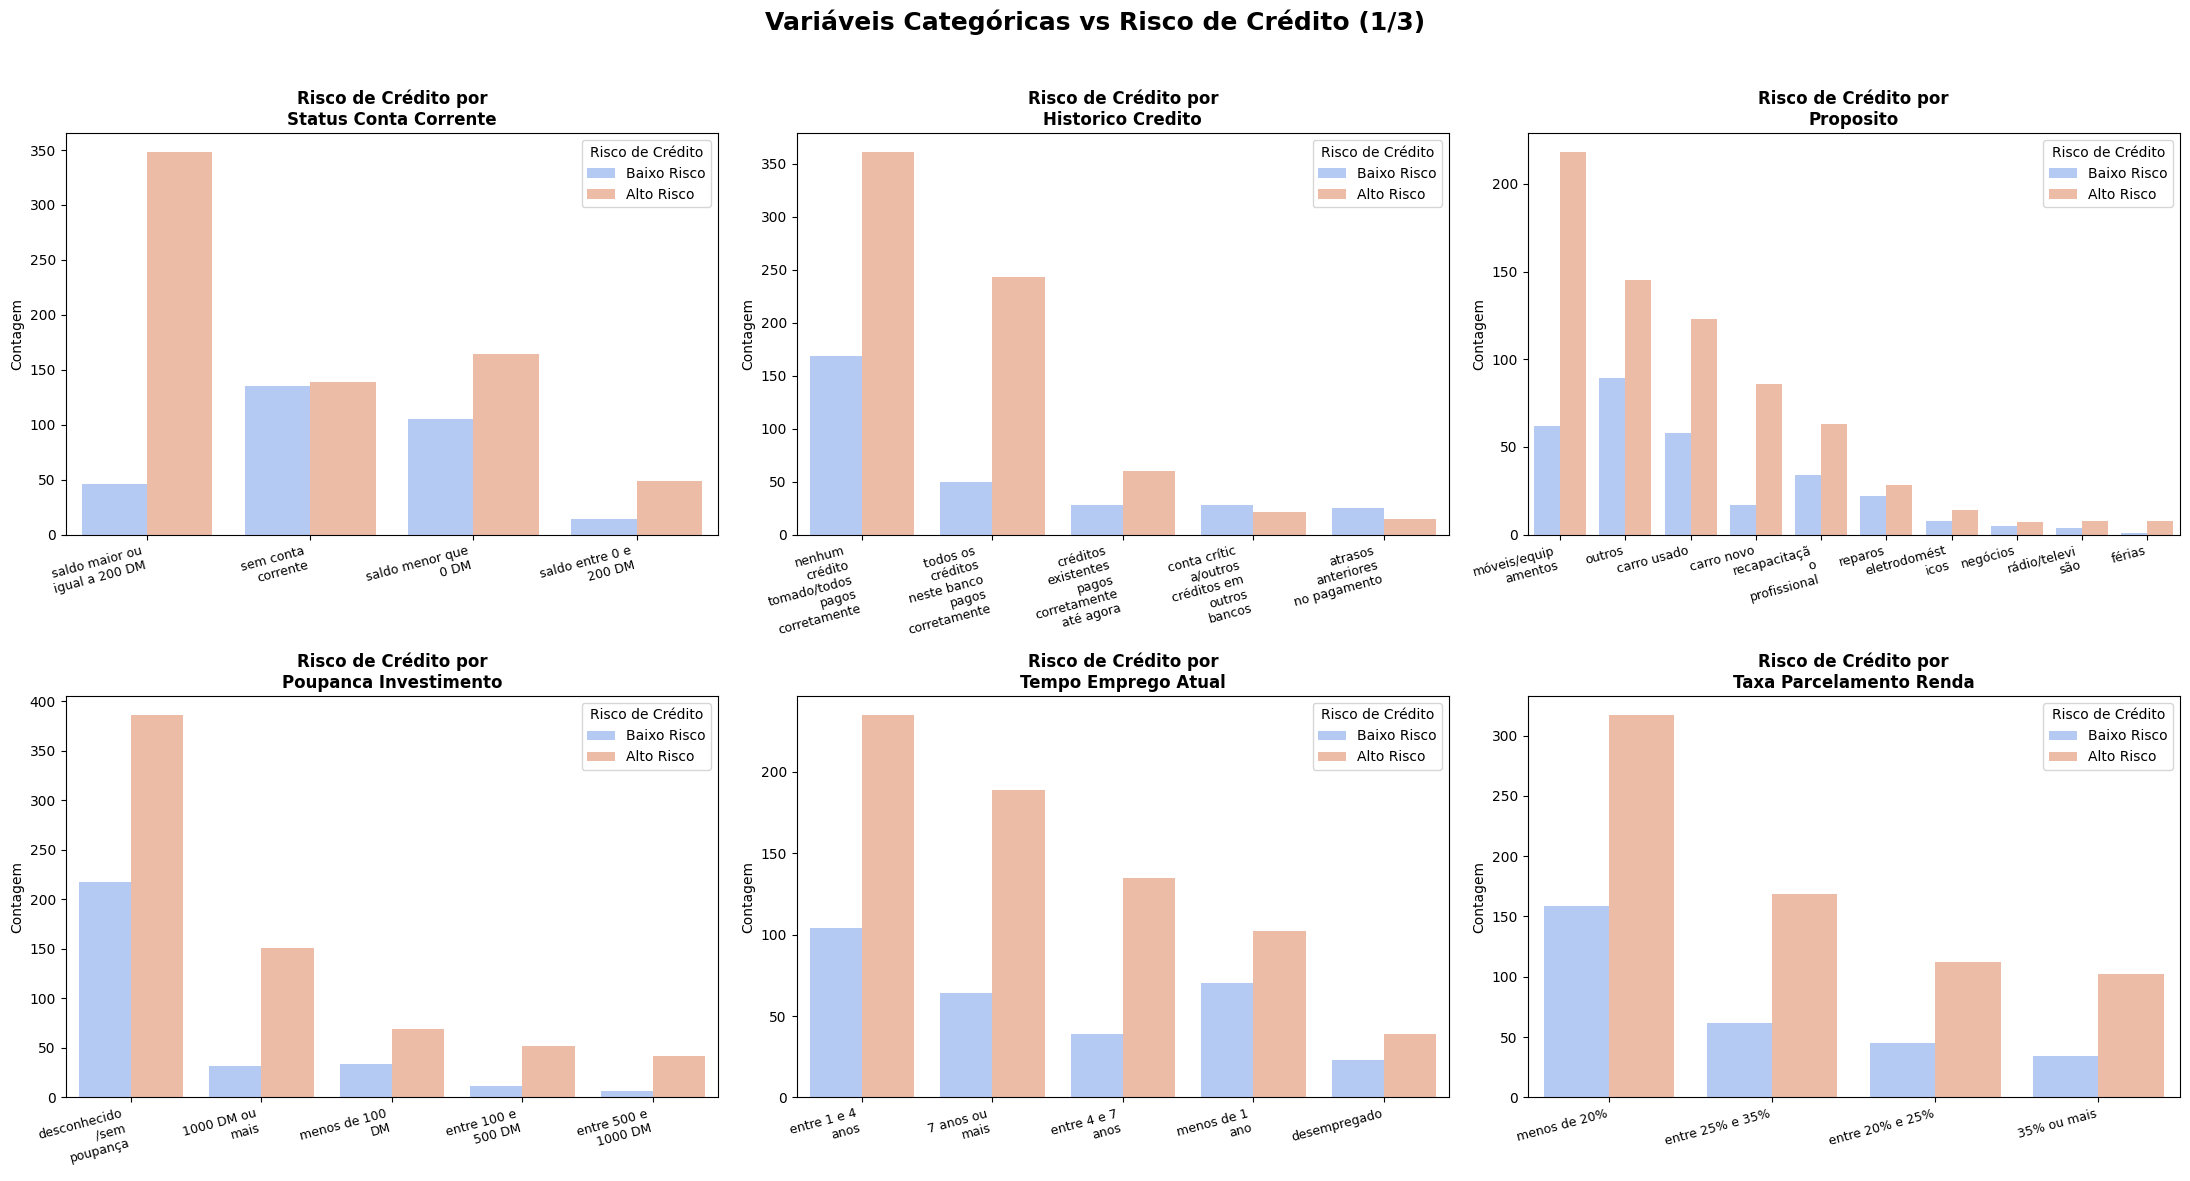

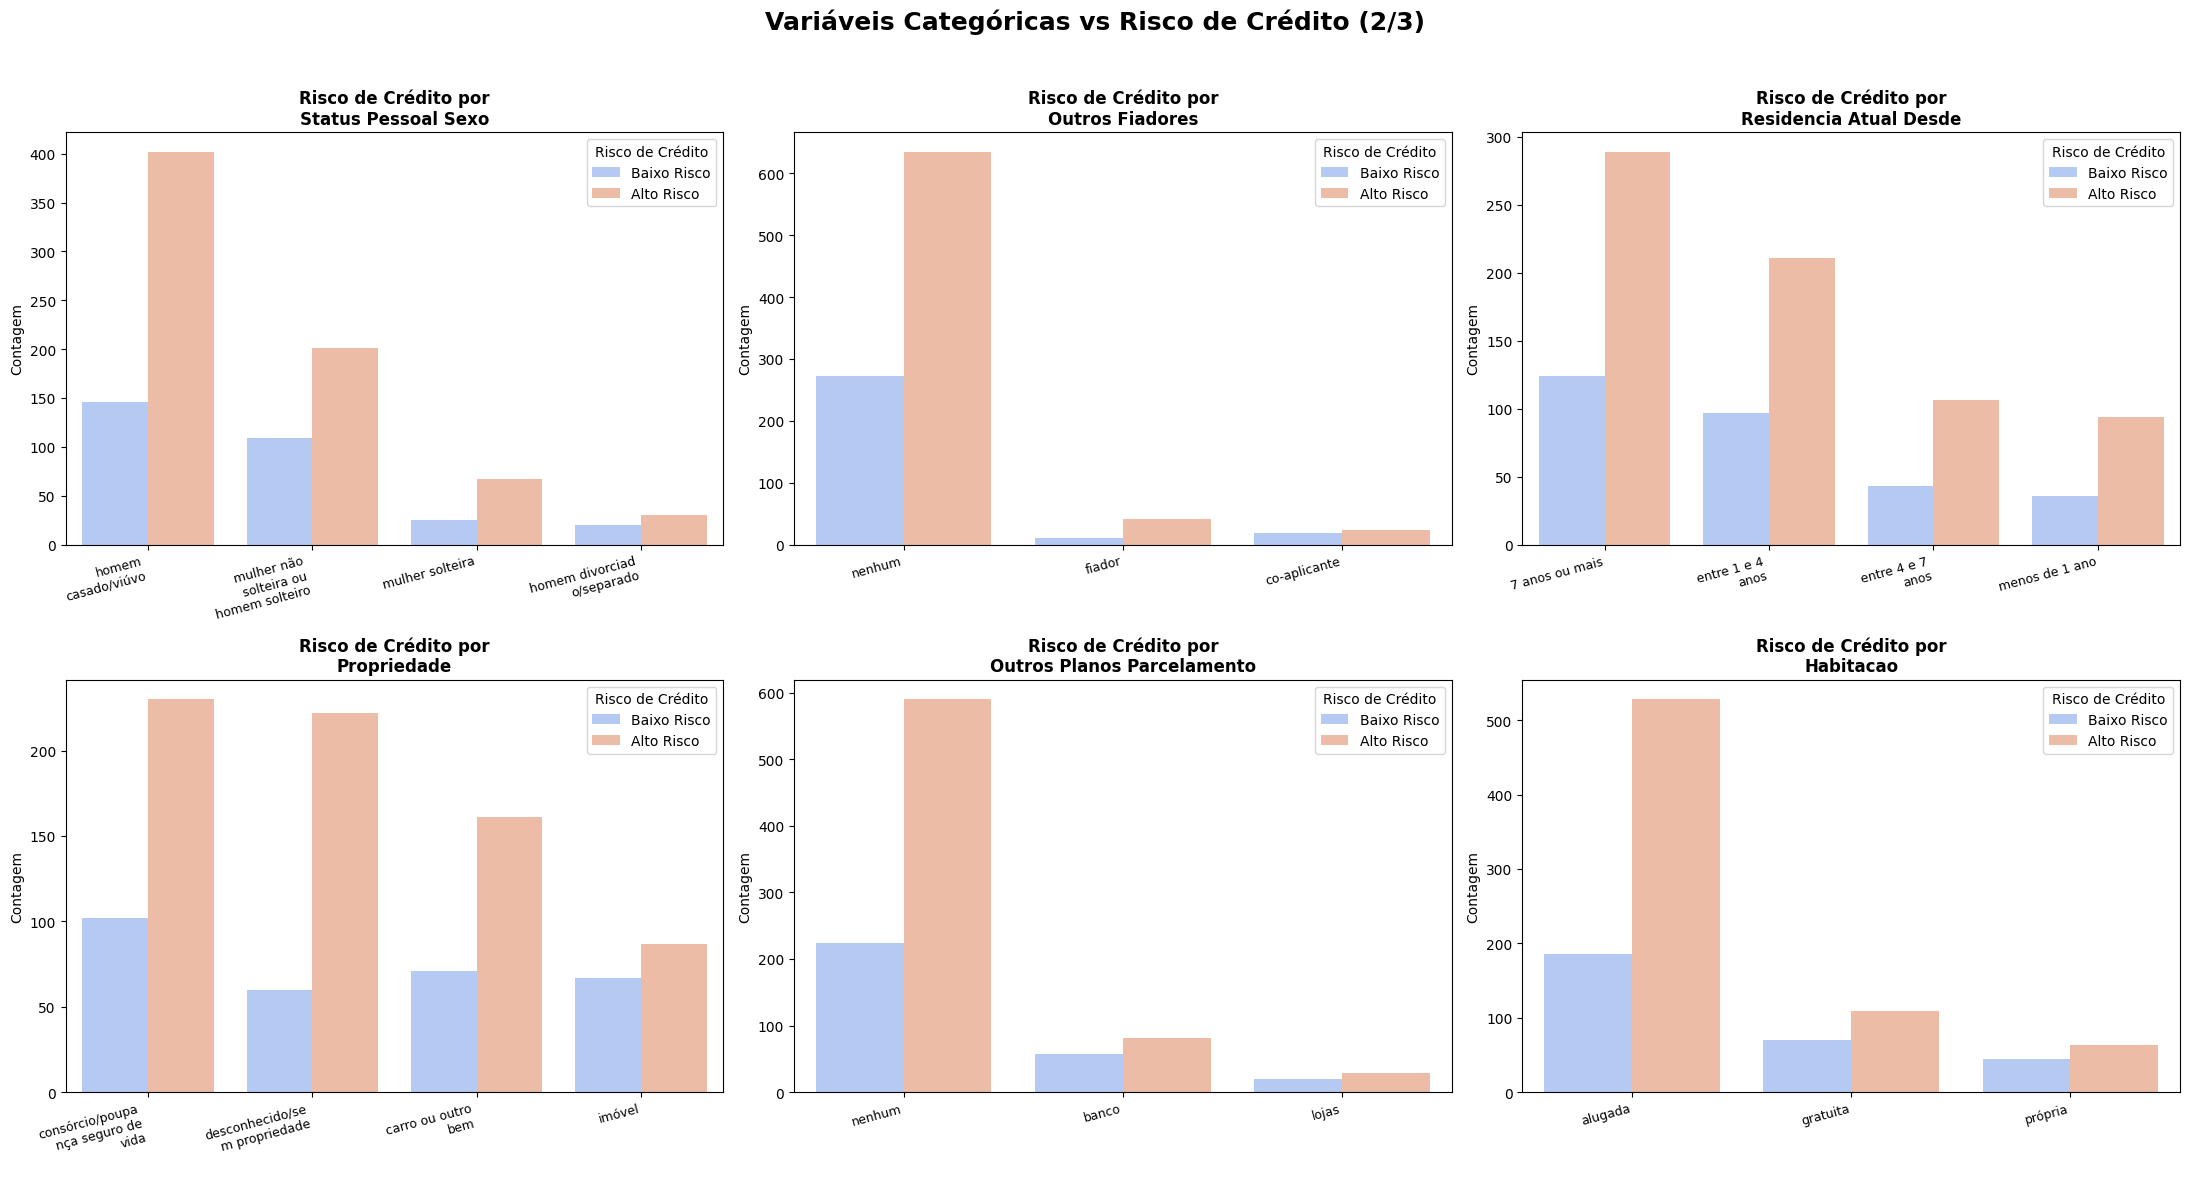

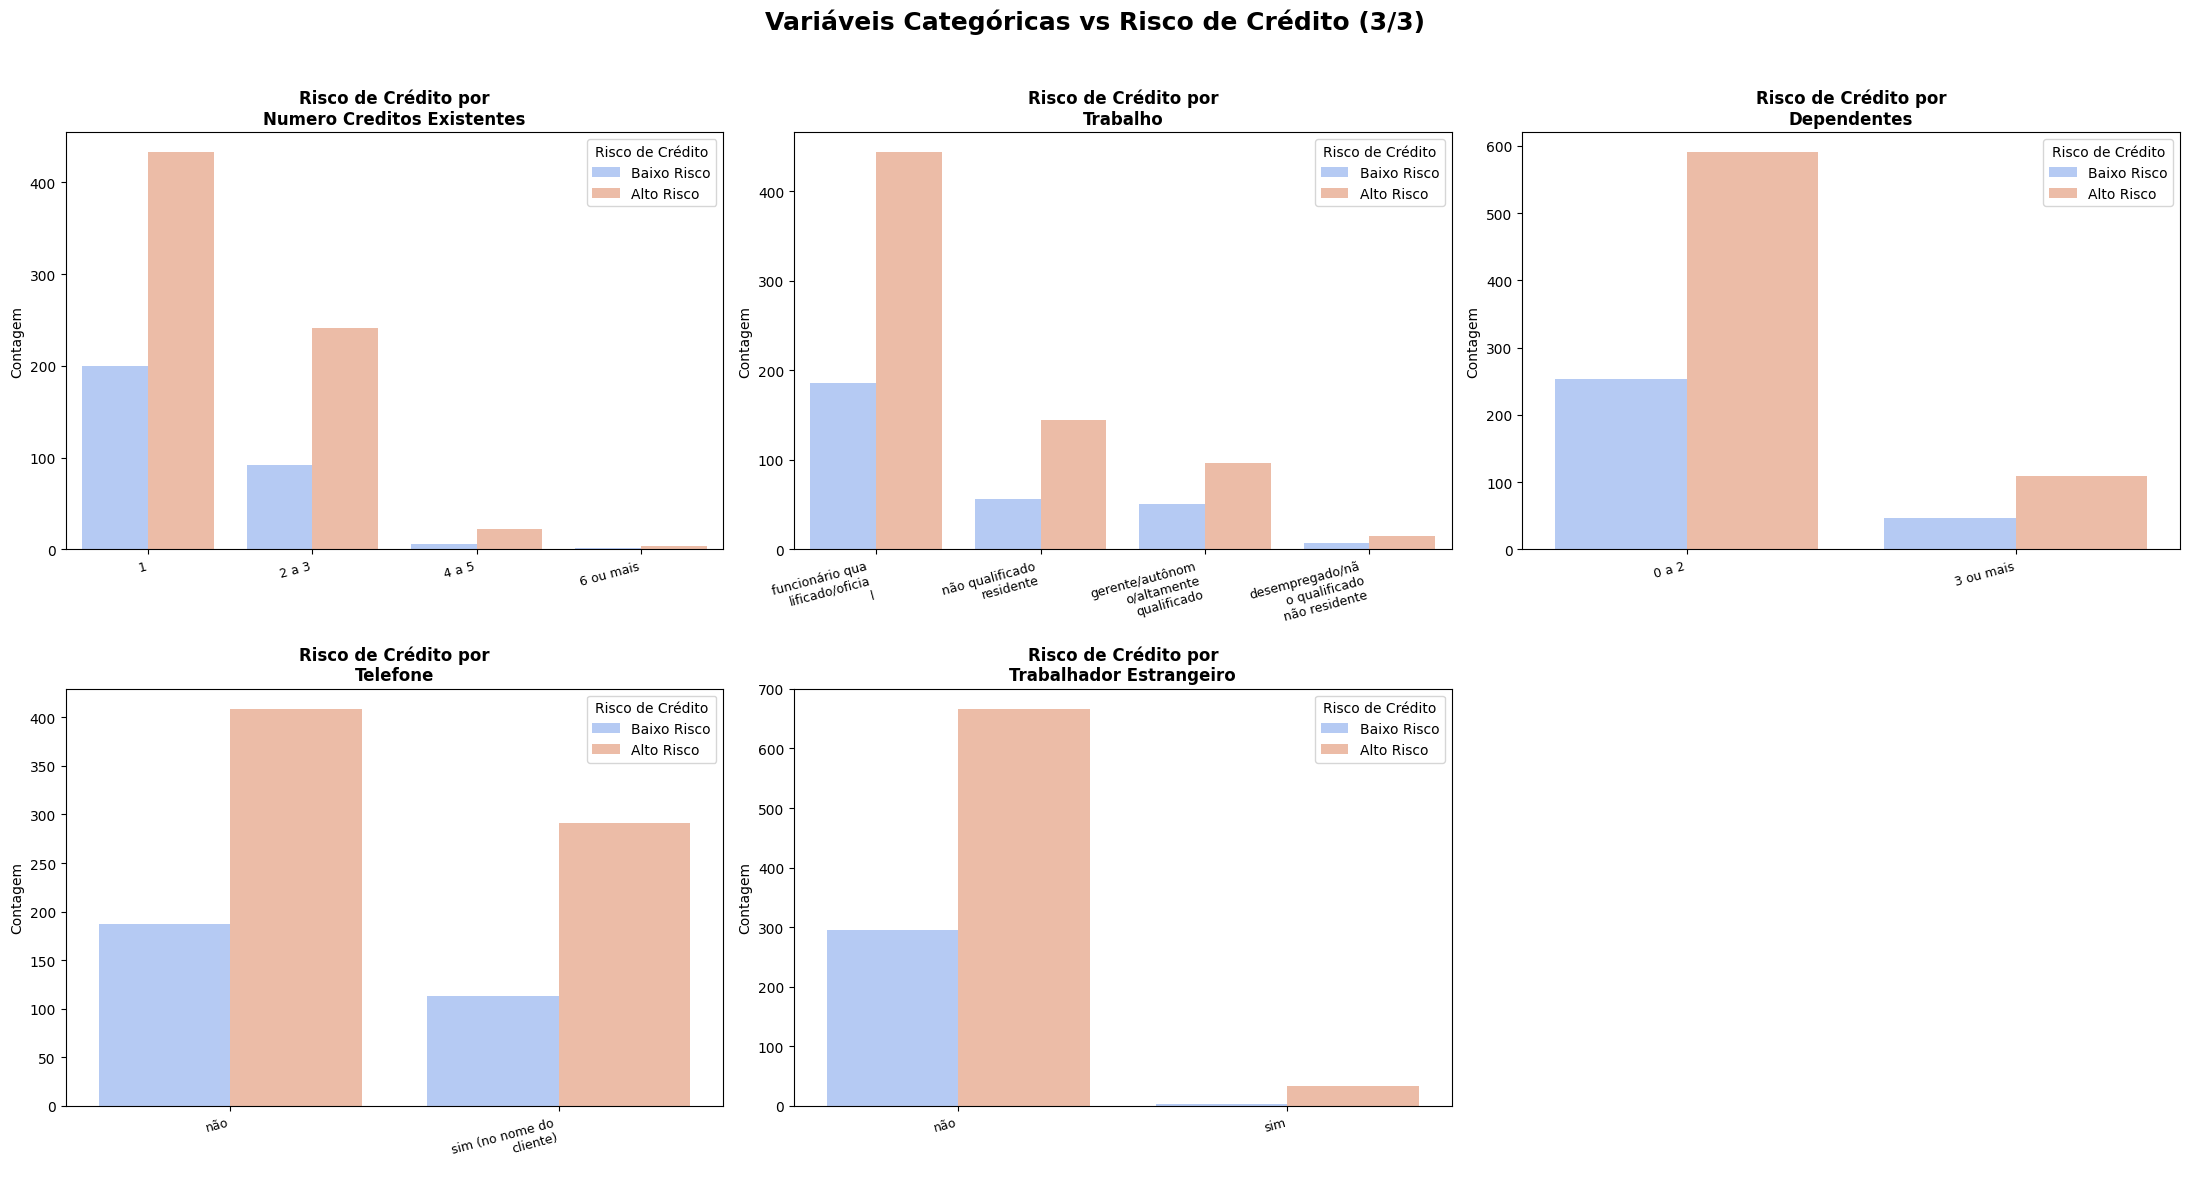

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import textwrap

# ==========================================
# COLUNAS CATEGÓRICAS
# ==========================================

categorical_cols = df_limpo.select_dtypes(exclude=[np.number]).columns

# Remove a target textual caso exista
categorical_cols = categorical_cols.drop('risco_credito', errors='ignore')

# ==========================================
# CONFIGURAÇÕES
# ==========================================

graficos_por_figura = 6

num_figuras = int(np.ceil(len(categorical_cols) / graficos_por_figura))

# ==========================================
# GERAÇÃO DOS GRÁFICOS
# ==========================================

for fig_num in range(num_figuras):

    inicio = fig_num * graficos_por_figura
    fim = inicio + graficos_por_figura

    cols_bloco = categorical_cols[inicio:fim]

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))

    axes = axes.flatten()

    # ==========================================
    # LOOP DOS GRÁFICOS
    # ==========================================

    for i, col in enumerate(cols_bloco):

        ax = axes[i]

        # Ordem das categorias
        ordem = df_limpo[col].value_counts().index

        sns.countplot(
            data=df_limpo,
            x=col,
            hue='risco_credito',
            order=ordem,
            palette='coolwarm',
            ax=ax
        )

        # ==========================================
        # FORMATAÇÃO DAS LABELS
        # ==========================================

        # Ajuste especial para labels longas
        largura_wrap = 12 if len(ordem) > 4 else 15

        labels_formatadas = [
            "\n".join(textwrap.wrap(str(label), width=largura_wrap))
            for label in ordem
        ]

        ax.set_xticks(range(len(ordem)))

        ax.set_xticklabels(
            labels_formatadas,
            rotation=15,
            ha='right',
            fontsize=9
        )

        # ==========================================
        # TÍTULO
        # ==========================================

        titulo = col.replace("_", " ").title()

        ax.set_title(
            f'Risco de Crédito por\n{titulo}',
            fontsize=12,
            fontweight='bold'
        )

        ax.set_xlabel("")
        ax.set_ylabel("Contagem")

        # ==========================================
        # LEGENDA
        # ==========================================

        handles, labels = ax.get_legend_handles_labels()

        ax.legend(
            handles,
            ['Baixo Risco', 'Alto Risco'],
            title='Risco de Crédito'
        )

    # ==========================================
    # REMOVE SUBPLOTS VAZIOS
    # ==========================================

    for j in range(len(cols_bloco), len(axes)):
        fig.delaxes(axes[j])

    # ==========================================
    # AJUSTES FINAIS
    # ==========================================

    plt.suptitle(
        f'Variáveis Categóricas vs Risco de Crédito ({fig_num + 1}/{num_figuras})',
        fontsize=18,
        fontweight='bold'
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    plt.show()